Importing and downloading dataset

In [1]:
!pip install -q ultralytics opencv-python numpy matplotlib kaggle

import xml.etree.ElementTree as ET
from glob import glob
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
from ultralytics import YOLO

print("All libraries installed and imported.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All libraries installed and imported.


In [2]:
import kagglehub

path = kagglehub.dataset_download("andrewmvd/car-plate-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-plate-detection' dataset.
Path to dataset files: /kaggle/input/car-plate-detection


In [3]:
dataset_images = os.path.join(path, 'images')
dataset_labels = os.path.join(path, 'annotations')
labels_dir = '/content/labels'
os.makedirs(labels_dir, exist_ok=True)

Preprocessing for YOLO

In [4]:
def convert_xml_to_yolo(xml_path, output_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find('size')
    img_w = int(size.find('width').text)
    img_h = int(size.find('height').text)

    with open(output_path, 'w') as f:
        for obj in root.findall('object'):
            b = obj.find('bndbox')
            xmin = float(b.find('xmin').text)
            ymin = float(b.find('ymin').text)
            xmax = float(b.find('xmax').text)
            ymax = float(b.find('ymax').text)

            x = (xmin + xmax) / (2 * img_w)
            y = (ymin + ymax) / (2 * img_h)
            w = (xmax - xmin) / img_w
            h = (ymax - ymin) / img_h
            f.write(f"0 {x} {y} {w} {h}\n")

In [5]:
xml_files = glob(os.path.join(dataset_labels, "*.xml"))
for xml_file in xml_files:
    txt_name = os.path.basename(xml_file).replace('.xml', '.txt')
    convert_xml_to_yolo(xml_file, os.path.join(labels_dir, txt_name))

In [6]:
import shutil

train_images_dir = '/content/train/images'
train_labels_dir = '/content/train/labels'
os.makedirs(train_images_dir, exist_ok=True)
os.makedirs(train_labels_dir, exist_ok=True)

for img_path in glob(os.path.join(dataset_images, "*.png")):
    shutil.copy(img_path, train_images_dir)

for label_path in glob(os.path.join(labels_dir, "*.txt")):
    shutil.copy(label_path, train_labels_dir)

In [7]:
with open('data.yaml', 'w') as f:
    f.write("path: /content/train\n")
    f.write("train: images\n")
    f.write("val: images\n")
    f.write("nc: 1\n")
    f.write("names: ['license-plate']\n")

In [8]:
model = YOLO('yolov8n.pt')
model.train(data='data.yaml', epochs=10, imgsz=640, batch=8)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79fa6e2ab560>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

The next part builds and applies color-matched perturbation patches around detected license plates.

Applying patches

In [9]:
car_model = YOLO('yolov8n.pt')

In [26]:
def get_car_color(img, car_box):
    x1, y1, x2, y2 = map(int, car_box)
    crop = img[y1:y2, x1:x2]
    # Sample a small area from the center of the car to avoid background/plate
    h, w, _ = crop.shape
    sample = crop[h//4:h//2, w//4:w//2]
    return np.mean(sample, axis=(0, 1)).astype(int)

In [27]:
def create_perturbed_patch(color, size, epsilon=20):
    patch = np.full((size, size, 3), color, dtype=np.uint8)
    noise = np.random.randint(-epsilon, epsilon, (size, size, 3))
    patch = np.clip(patch + noise, 0, 255).astype(np.uint8)
    return patch

In [28]:
def apply_color_patch(img, patch, x, y):
    size = patch.shape[0]
    for i in range(size):
        for j in range(size):
            if 0 <= y+i < img.shape[0] and 0 <= x+j < img.shape[1]:
                img[y+i, x+j] = patch[i, j]

In [29]:
from glob import glob
image_files = sorted(glob(os.path.join(dataset_images, "*.png")))
test_img_path = image_files[7]
img = cv2.imread(test_img_path)
attacked_img = img.copy()

car_results = car_model(test_img_path, verbose=False)[0]
plate_results = model(test_img_path, verbose=False)[0]

In [14]:
car_color = [128, 128, 128]
for box in car_results.boxes:
    if int(box.cls[0]) == 2: # 'car' class in COCO
        car_color = get_car_color(img, box.xyxy[0].cpu().numpy())
        break

for box in plate_results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
    p_size = int((y2 - y1) * 0.9)

    patch = create_perturbed_patch(car_color, p_size)

    apply_color_patch(attacked_img, patch, x1 - (p_size//2), y1)
    apply_color_patch(attacked_img, patch, x2 - (p_size//2), y1)

In [30]:
attacked_img = img.copy()

for box in plate_results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
    pw = x2 - x1
    ph = y2 - y1
    p_size = int(ph * 0.9)

    patch = create_perturbed_patch(car_color, p_size)

    apply_color_patch(attacked_img, patch, x1 - (p_size//2), y1)
    apply_color_patch(attacked_img, patch, x2 - (p_size//2), y1)

    apply_color_patch(attacked_img, patch, x1 + (pw//2) - (p_size//2), y1 - int(p_size * 0.95))
    apply_color_patch(attacked_img, patch, x1 + (pw//2) - (p_size//2), y2 + int(p_size * 0.00005))

In [31]:
cv2.imwrite('four_patch_attack.jpg', attacked_img)
final_res = model('four_patch_attack.jpg')

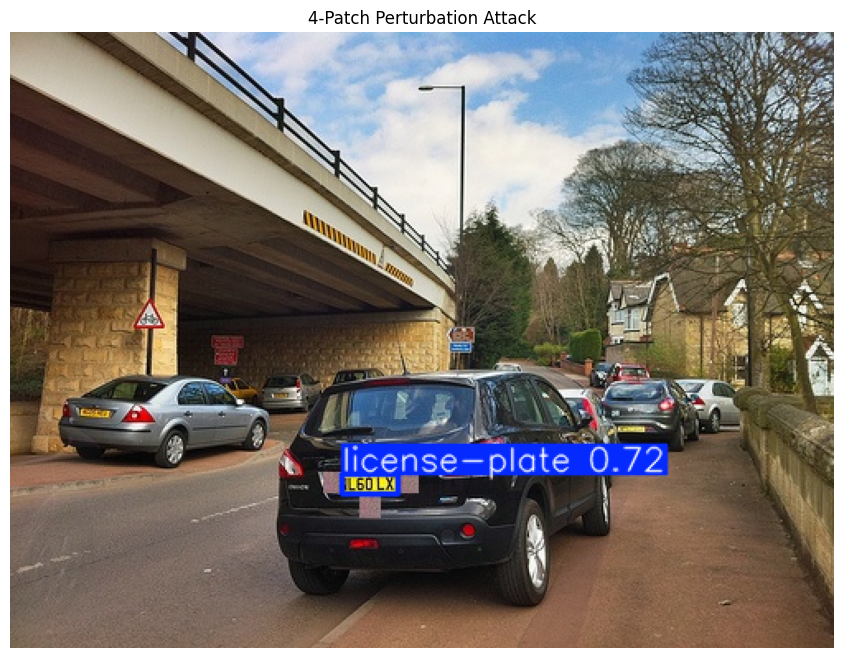

In [32]:
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(final_res[0].plot(), cv2.COLOR_BGR2RGB))
plt.title("4-Patch Perturbation Attack")
plt.axis('off')
plt.show()

This section visualizes an attacked sample and then computes post-attack recall using IoU-based matching.

In [33]:
results_dict_color = {
    "original_count": 0,
    "attacked_count": 0,
    "confidence_drop": []
}

In [34]:
output_dir_color = '/content/color_attack_results'
os.makedirs(output_dir_color, exist_ok=True)

In [35]:
import pandas as pd

def get_ground_truth(label_path):
    gt_boxes = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                cls, x, y, w, h = map(float, line.split())
                gt_boxes.append([x, y, w, h])
    return gt_boxes

In [36]:
stats = {"tp": 0, "fp": 0, "fn": 0}
iou_threshold = 0.5

for img_name in os.listdir(output_dir_color):
    label_name = img_name.replace('.png', '.txt').replace('.jpg', '.txt')
    gt_path = os.path.join(train_labels_dir, label_name)
    gt_boxes = get_ground_truth(gt_path)

    res = model(os.path.join(output_dir_color, img_name), verbose=False)[0]
    pred_boxes = res.boxes.xywhn.cpu().numpy() if len(res.boxes) > 0 else []

    matched_gt = set()
    for p_box in pred_boxes:
        found_match = False
        for i, g_box in enumerate(gt_boxes):
            if i in matched_gt: continue

            # Simple IoU calculation
            i_x1, i_y1 = max(p_box[0]-p_box[2]/2, g_box[0]-g_box[2]/2), max(p_box[1]-p_box[3]/2, g_box[1]-g_box[3]/2)
            i_x2, i_y2 = min(p_box[0]+p_box[2]/2, g_box[0]+g_box[2]/2), min(p_box[1]+p_box[3]/2, g_box[1]+g_box[3]/2)

            inter = max(0, i_x2 - i_x1) * max(0, i_y2 - i_y1)
            union = (p_box[2] * p_box[3]) + (g_box[2] * g_box[3]) - inter
            iou = inter / union if union > 0 else 0

            if iou >= iou_threshold:
                stats["tp"] += 1
                matched_gt.add(i)
                found_match = True
                break
        if not found_match:
            stats["fp"] += 1

    stats["fn"] += (len(gt_boxes) - len(matched_gt))

In [37]:
recall = stats["tp"] / (stats["tp"] + stats["fn"]) if (stats["tp"] + stats["fn"]) > 0 else 0

print(f"Post-Attack Recall (Detection Accuracy): {recall:.2f}")


Post-Attack Recall (Detection Accuracy): 0.00


In [38]:
stats_pre = {"tp": 0, "fp": 0, "fn": 0}
iou_threshold = 0.5

The final evaluation loop computes pre-attack recall on clean images for direct comparison.

In [39]:
for img_path in image_files[:50]:
    img_name = os.path.basename(img_path)
    label_name = img_name.replace('.png', '.txt').replace('.jpg', '.txt')
    gt_path = os.path.join(train_labels_dir, label_name)
    gt_boxes = get_ground_truth(gt_path)

    res = model(img_path, verbose=False)[0]
    pred_boxes = res.boxes.xywhn.cpu().numpy() if len(res.boxes) > 0 else []

    matched_gt = set()
    for p_box in pred_boxes:
        found_match = False
        for i, g_box in enumerate(gt_boxes):
            if i in matched_gt: continue

            i_x1, i_y1 = max(p_box[0]-p_box[2]/2, g_box[0]-g_box[2]/2), max(p_box[1]-p_box[3]/2, g_box[1]-g_box[3]/2)
            i_x2, i_y2 = min(p_box[0]+p_box[2]/2, g_box[0]+g_box[2]/2), min(p_box[1]+p_box[3]/2, g_box[1]+g_box[3]/2)

            inter = max(0, i_x2 - i_x1) * max(0, i_y2 - i_y1)
            union = (p_box[2] * p_box[3]) + (g_box[2] * g_box[3]) - inter
            iou = inter / union if union > 0 else 0

            if iou >= iou_threshold:
                stats_pre["tp"] += 1
                matched_gt.add(i)
                found_match = True
                break
        if not found_match:
            stats_pre["fp"] += 1

    stats_pre["fn"] += (len(gt_boxes) - len(matched_gt))

In [40]:
pre_recall = stats_pre["tp"] / (stats_pre["tp"] + stats_pre["fn"]) if (stats_pre["tp"] + stats_pre["fn"]) > 0 else 0

print(f"Pre-Attack Recall (Accuracy): {pre_recall:.2f}")

Pre-Attack Recall (Accuracy): 0.86
